# Pooling and model diagnostics
Inspect calibration, saturation, coverage, and sequence representation before interpreting performance.

In [1]:
from pathlib import Path
import os
ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
import json
import pandas as pd
from IPython.display import display, Image
from m6a_project.training import load_config, run_experiment
from m6a_project.tracking import rebuild_index
from m6a_project.cache import prepare_data
CONFIG = load_config("configs/experiments/baselines_v1.toml")


In [2]:
table = pd.read_csv("docs/results/comparison.csv")
display(table[["approach", "model", "log_loss", "brier_score", "fraction_score_ge_099"]])

,approach,model,log_loss,brier_score,fraction_score_ge_099
0,site_mean9,dummy,0.178984,0.041621,0.000000
1,site_mean9,logistic,0.167511,0.040571,0.000000
2,read9_noisy_or,logistic,0.890638,0.332252,0.000000
3,read15_noisy_or,logistic,0.872905,0.294377,0.007771
4,site_mean9,hist_boosting,0.126461,0.032065,0.000000
5,read9_noisy_or,hist_boosting,0.826393,0.271313,0.019724
6,read15_noisy_or,hist_boosting,0.806836,0.237489,0.034714
7,site_mean9,random_forest,0.130682,0.033298,0.000000
8,read9_noisy_or,random_forest,0.833608,0.284619,0.012347
9,read15_noisy_or,random_forest,0.819643,0.253001,0.026272


logistic experiments/data0_baselines_v1/20261005T075020_read15_noisy_or_logistic_0af128c6


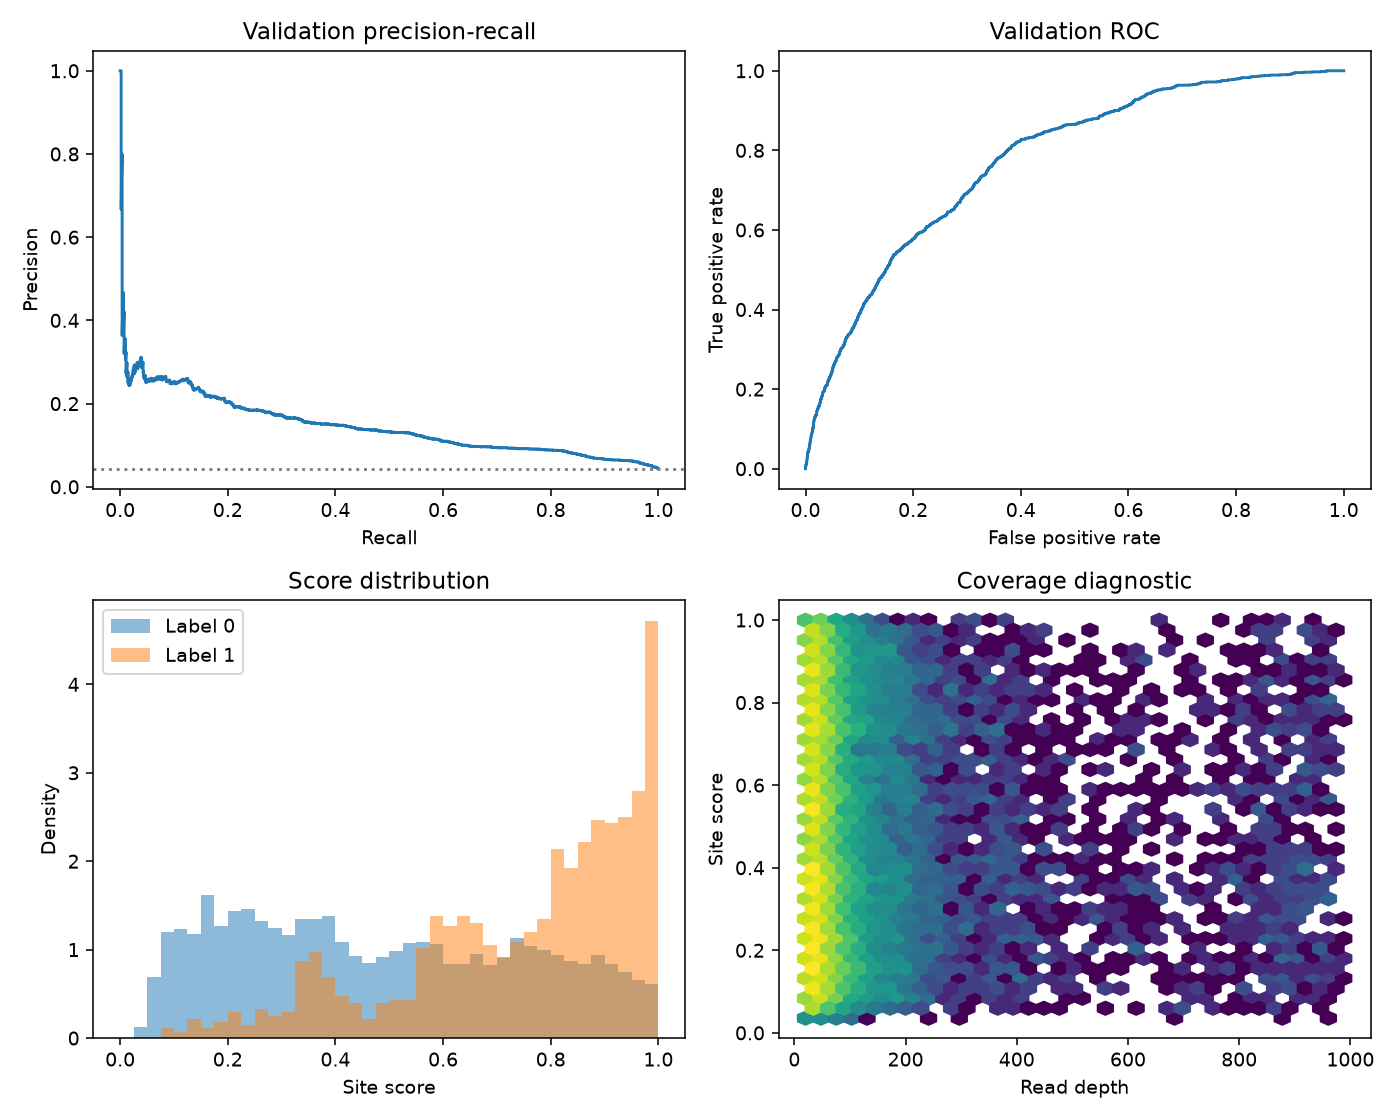

hist_boosting experiments/data0_baselines_v1/20261005T075050_read15_noisy_or_hist_boosting_c6e9c56d


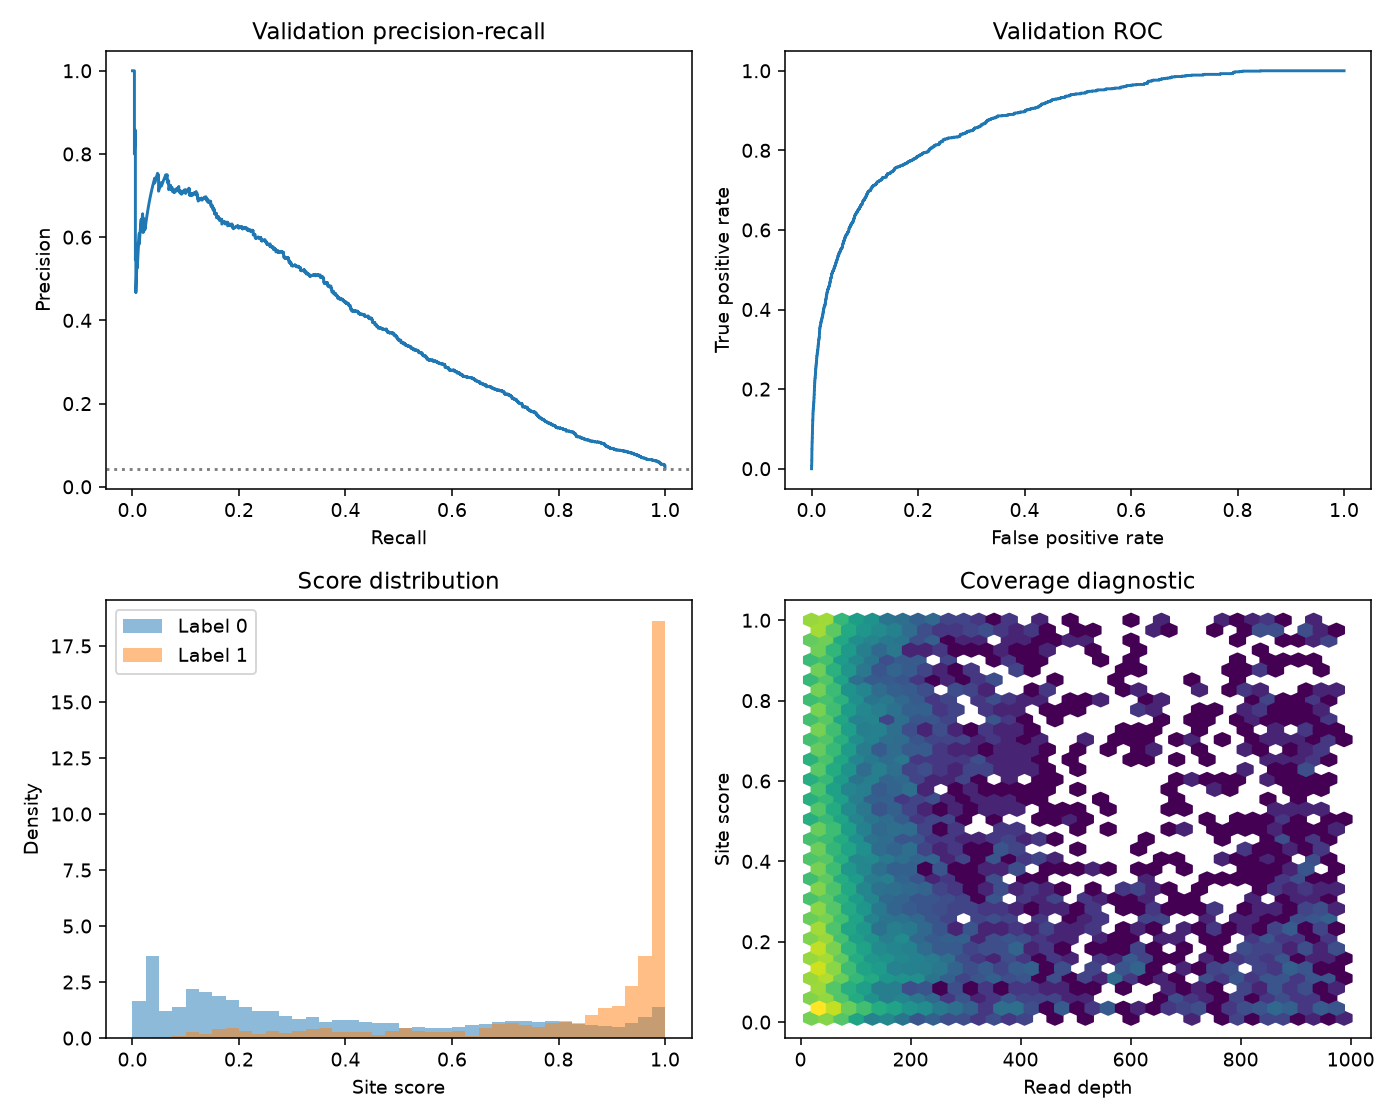

random_forest experiments/data0_baselines_v1/20261005T075234_read15_noisy_or_random_forest_95f55ef5


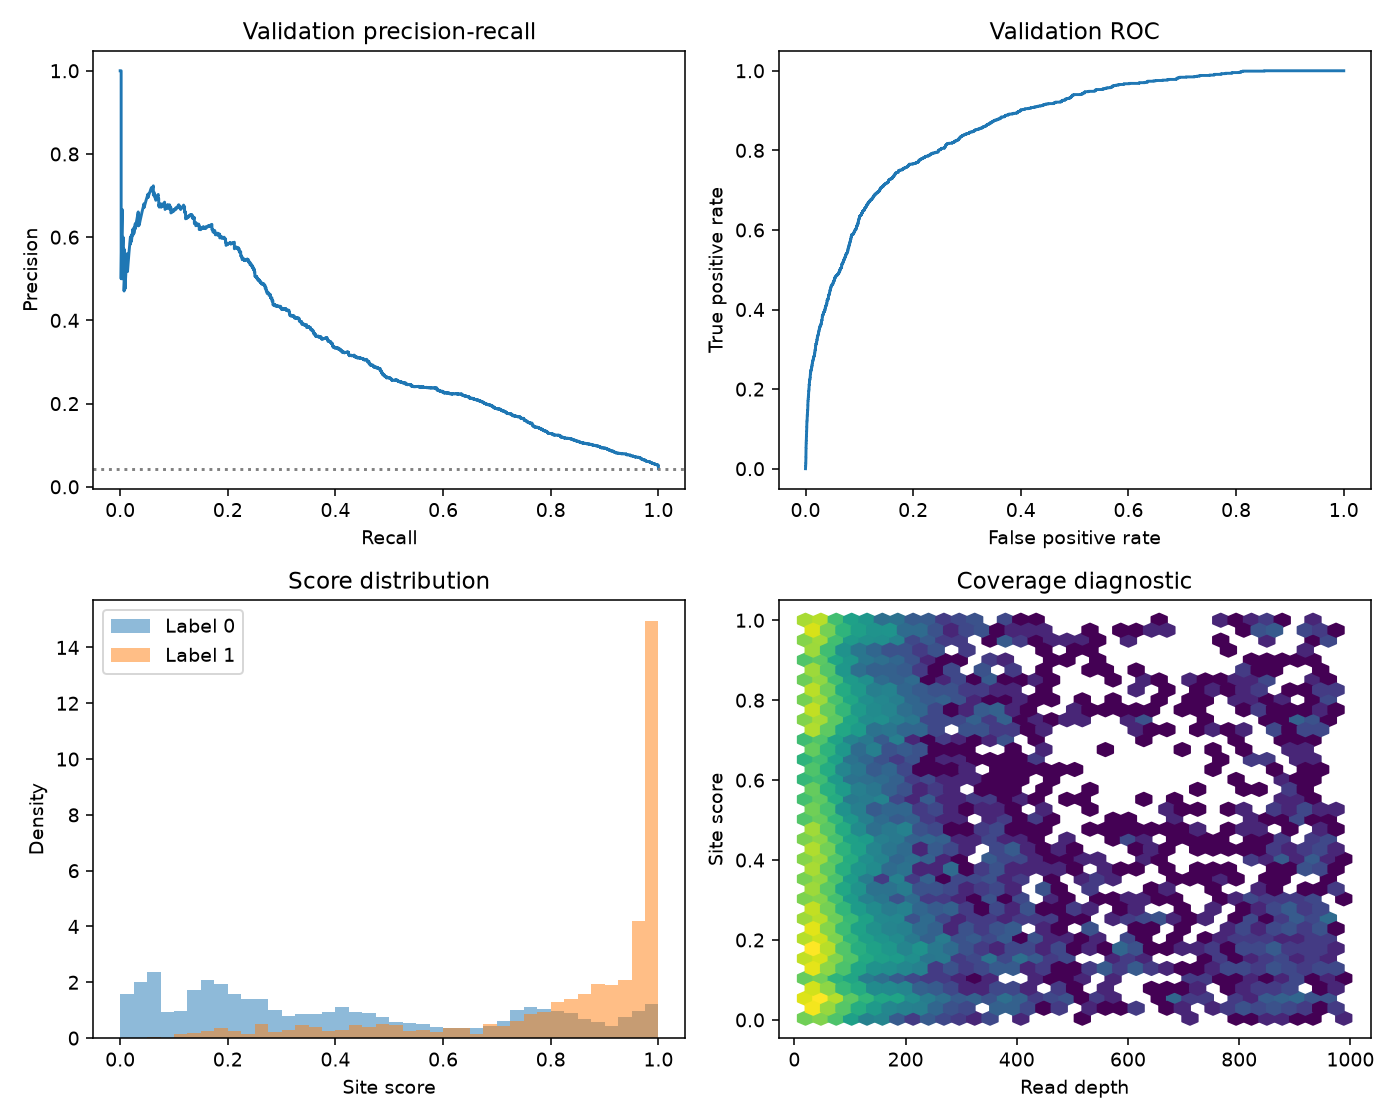

In [3]:
for model in ["logistic", "hist_boosting", "random_forest"]:
    selected = table[(table.model == model) & (table.approach == "read15_noisy_or")].iloc[-1]
    print(model, selected.run_path)
    display(Image(filename=str(Path(selected.run_path) / "diagnostics.png")))

In [4]:
selected = table[(table.model == "logistic") & (table.approach == "read15_noisy_or")].iloc[-1]
run_dir = Path(selected.run_path)
display(pd.read_csv(run_dir / "calibration.csv"))
display(pd.read_csv(run_dir / "motif_metrics.csv"))
print(json.loads((run_dir / "embedding.json").read_text())["explained_variance_ratio"])

,score_bin,sites,mean_score,observed_rate
0,"(-0.001, 0.1]",1221,0.078105,0.002457
1,"(0.1, 0.2]",3224,0.151040,0.004963
2,"(0.2, 0.3]",3343,0.248220,0.008376
3,"(0.3, 0.4]",3252,0.351712,0.023985
4,"(0.4, 0.5]",2336,0.447988,0.017551
5,"(0.5, 0.6]",2641,0.550986,0.034078
6,"(0.6, 0.7]",2234,0.650416,0.061773
7,"(0.7, 0.8]",2609,0.750731,0.047911
8,"(0.8, 0.9]",2414,0.850237,0.099834
9,"(0.9, 1.0]",2076,0.948235,0.165222


,motif,sites,prevalence,mean_score,average_precision,roc_auc
0,AAACA,2150,0.002326,0.174391,0.003683,0.481305
1,AAACC,1323,0.000000,0.088730,NaN,NaN
2,AAACT,1868,0.027837,0.283692,0.047351,0.556676
3,AGACA,1611,0.024829,0.493532,0.038550,0.610678
4,AGACC,1329,0.012792,0.302936,0.011559,0.430954
5,AGACT,1301,0.081476,0.677577,0.120083,0.605763
6,GAACA,1648,0.021238,0.674700,0.021013,0.406802
7,GAACC,1195,0.014226,0.439769,0.055300,0.645461
8,GAACT,1480,0.114865,0.810966,0.120667,0.507503
9,GGACA,1531,0.080340,0.804360,0.093019,0.520568


[0.2644508832474579, 0.20176073210795645]


Noisy-OR scores from inherited-label training are not established read modification probabilities. Saturation and calibration errors must be reported. No stoichiometry estimate or claim of superiority to official m6Anet is made.